In [ ]:
# === 1. PREPROCESSING CELL (run once) ===
# Upload your Loan_default.csv to Colab or change the path below.
# If you uploaded via Colab file browser, use "/content/Loan_default.csv".
CSV_PATH = "Loan_default.csv"  # change if needed

# If your file is still at /mnt/data in this environment, use:
# CSV_PATH = "/mnt/data/Loan_default.csv"

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load
df = pd.read_csv(CSV_PATH)
print("Loaded shape:", df.shape)
print("Columns:", df.columns.tolist())

# Basic cleanup based on the file inspected:
if "LoanID" in df.columns:
    df = df.drop(columns=["LoanID"])

# Convert Yes/No to 1/0 for binary columns where applicable
bin_map = {"Yes":1, "No":0}
for c in ["HasCoSigner", "HasDependents"]:
    if c in df.columns and df[c].dtype == object:
        df[c] = df[c].map(bin_map)

# If Month-like column named weirdly, try to standardize names (optional)
# (this is safe — will only rename if matching)
rename_map = {}
if "Month...gage" in df.columns:
    rename_map["Month...gage"] = "MonthsEmployed"
if rename_map:
    df = df.rename(columns=rename_map)

# Handle missing values simply (drop rows with missing)
print("Missing per column:\n", df.isna().sum()[df.isna().sum()>0])
df = df.dropna().reset_index(drop=True)
print("After dropna shape:", df.shape)

# Target and features
TARGET = "Default"
if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' not found in data")

y = df[TARGET].astype(int)
X = df.drop(columns=[TARGET])

# One-hot encode categorical columns (except binary mapped above)
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
if len(cat_cols)>0:
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print("Feature matrix shape after dummies:", X.shape)

# Train/test split (stratify by target)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# Scaler for models that need scaling
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save to disk if you want (optional)
import pickle
with open("preprocessed_data.pkl", "wb") as f:
    pickle.dump({
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
        "X_train_scaled": X_train_scaled, "X_test_scaled": X_test_scaled,
        "scaler": scaler
    }, f)

print("Preprocessing finished. Ready to run model cells.")
print("X_train shape:", X_train.shape, "X_train_scaled shape:", X_train_scaled.shape)


Loaded shape: (255347, 18)
Columns: ['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']
Missing per column:
 Series([], dtype: int64)
After dropna shape: (255347, 17)
Feature matrix shape after dummies: (255347, 24)
Preprocessing finished. Ready to run model cells.
X_train shape: (204277, 24) X_train_scaled shape: (204277, 24)


In [9]:
# === 2. EVALUATION FUNCTIONS (run once) ===
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_and_print(y_true, y_pred, label="Model"):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    sens = recall_score(y_true, y_pred)  # sensitivity = recall for positive class
    f1 = f1_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    print(f"=== {label} ===")
    print(f"Train/Test sizes: {len(y_train)} / {len(y_test)}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Sensitivity (Recall for class 1): {sens:.4f}")
    print(f"Specificity (TN / (TN+FP)): {spec:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"F1 score: {f1:.4f}")
    print("Confusion matrix (tn, fp, fn, tp):", (tn, fp, fn, tp))
    print()


In [10]:
# === LOGISTIC REGRESSION ===
# Uses scaled features
!pip install -q scikit-learn
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')
lr.fit(X_train_scaled, y_train)

# Evaluate on train and test
y_train_pred = lr.predict(X_train_scaled)
y_test_pred = lr.predict(X_test_scaled)

print("Train metrics:")
evaluate_and_print(y_train, y_train_pred, label="Logistic Regression (train)")
print("Test metrics:")
evaluate_and_print(y_test, y_test_pred, label="Logistic Regression (test)")


Train metrics:
=== Logistic Regression (train) ===
Train/Test sizes: 204277 / 51070
Accuracy: 0.8851
Sensitivity (Recall for class 1): 0.0337
Specificity (TN / (TN+FP)): 0.9970
Precision: 0.5935
F1 score: 0.0638
Confusion matrix (tn, fp, fn, tp): (np.int64(180007), np.int64(548), np.int64(22922), np.int64(800))

Test metrics:
=== Logistic Regression (test) ===
Train/Test sizes: 204277 / 51070
Accuracy: 0.8853
Sensitivity (Recall for class 1): 0.0341
Specificity (TN / (TN+FP)): 0.9971
Precision: 0.6084
F1 score: 0.0645
Confusion matrix (tn, fp, fn, tp): (np.int64(45009), np.int64(130), np.int64(5729), np.int64(202))



Before SMOTE: {0: 180555, 1: 23722}
After SMOTE: {0: 180555, 1: 180555}
=== SGD-SVM + SMOTE (default threshold) ===
Accuracy: 0.6921
Sensitivity (Recall for class 1): 0.6734
Specificity (TN / (TN+FP)): 0.6945
Precision: 0.2246
F1 score: 0.3368
Confusion matrix (tn, fp, fn, tp): (31349, 13790, 1937, 3994)
ROC-AUC: 0.7485936740582003
PR-AUC : 0.3029816292241122

Best threshold by F1: 0.578, F1=0.365
=== SGD-SVM tuned (thr=0.578) ===
Accuracy: 0.8083
Sensitivity (Recall for class 1): 0.4738
Specificity (TN / (TN+FP)): 0.8523
Precision: 0.2965
F1 score: 0.3647
Confusion matrix (tn, fp, fn, tp): (38472, 6667, 3121, 2810)


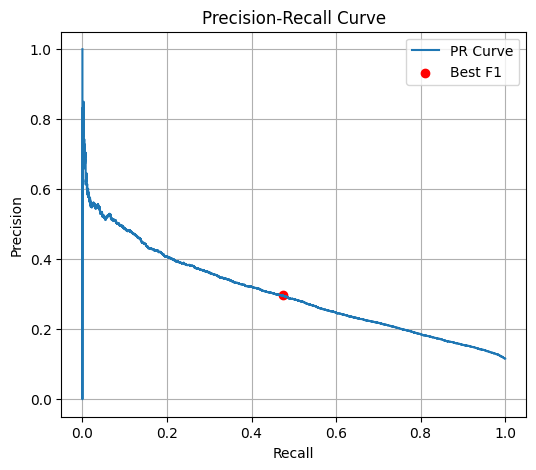

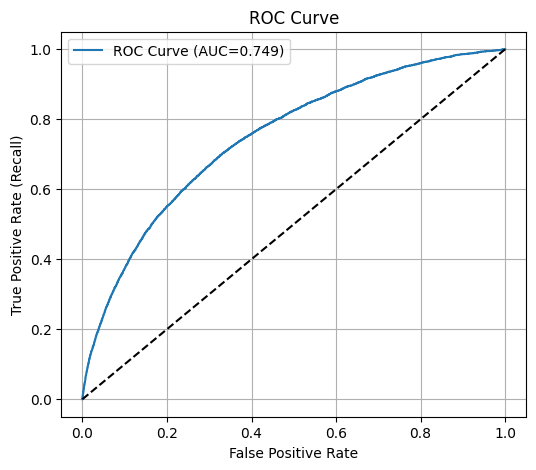

=== Threshold -1.00 ===
Accuracy: 0.4096
Sensitivity (Recall for class 1): 0.9059
Specificity (TN / (TN+FP)): 0.3444
Precision: 0.1537
F1 score: 0.2628
Confusion matrix (tn, fp, fn, tp): (15545, 29594, 558, 5373)
=== Threshold -0.96 ===
Accuracy: 0.4212
Sensitivity (Recall for class 1): 0.8992
Specificity (TN / (TN+FP)): 0.3584
Precision: 0.1555
F1 score: 0.2652
Confusion matrix (tn, fp, fn, tp): (16180, 28959, 598, 5333)
=== Threshold -0.92 ===
Accuracy: 0.4331
Sensitivity (Recall for class 1): 0.8938
Specificity (TN / (TN+FP)): 0.3726
Precision: 0.1577
F1 score: 0.2680
Confusion matrix (tn, fp, fn, tp): (16818, 28321, 630, 5301)
=== Threshold -0.88 ===
Accuracy: 0.4449
Sensitivity (Recall for class 1): 0.8859
Specificity (TN / (TN+FP)): 0.3869
Precision: 0.1596
F1 score: 0.2704
Confusion matrix (tn, fp, fn, tp): (17465, 27674, 677, 5254)
=== Threshold -0.84 ===
Accuracy: 0.4556
Sensitivity (Recall for class 1): 0.8798
Specificity (TN / (TN+FP)): 0.3999
Precision: 0.1615
F1 score: 0.2

In [19]:
# === Improved SGDClassifier-SVM with threshold tuning & AUC metrics ===

!pip install -q imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve, roc_curve, confusion_matrix
)
from imblearn.over_sampling import SMOTE

# Function to evaluate predictions
def evaluate_and_print(y_true, y_pred, label="Model"):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    recall = tp / (tp + fn)
    specificity = tn / (tn + fp)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall + 1e-6)

    print(f"=== {label} ===")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Sensitivity (Recall for class 1): {recall:.4f}")
    print(f"Specificity (TN / (TN+FP)): {specificity:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F1 score: {f1:.4f}")
    print(f"Confusion matrix (tn, fp, fn, tp): ({tn}, {fp}, {fn}, {tp})")
    return f1, precision, recall

# 1. Apply SMOTE to oversample minority class
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_scaled, y_train)
print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_res).value_counts().to_dict())

# 2. Train SGDClassifier with balanced weights
sgd_svm = SGDClassifier(loss="hinge", class_weight="balanced", max_iter=2000, tol=1e-3, random_state=42)
sgd_svm.fit(X_res, y_res)

# 3. Get decision scores on test set
y_test_scores = sgd_svm.decision_function(X_test_scaled)

# 4. Default threshold evaluation
y_test_pred_default = (y_test_scores > 0).astype(int)
evaluate_and_print(y_test, y_test_pred_default, label="SGD-SVM + SMOTE (default threshold)")
print("ROC-AUC:", roc_auc_score(y_test, y_test_scores))
print("PR-AUC :", average_precision_score(y_test, y_test_scores))

# 5. Threshold tuning to maximize F1
prec, rec, thresholds = precision_recall_curve(y_test, y_test_scores)
f1_scores = 2 * (prec * rec) / (prec + rec + 1e-6)
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
print(f"\nBest threshold by F1: {best_thresh:.3f}, F1={f1_scores[best_idx]:.3f}")

# Apply best threshold
y_test_pred_best = (y_test_scores > best_thresh).astype(int)
evaluate_and_print(y_test, y_test_pred_best, label=f"SGD-SVM tuned (thr={best_thresh:.3f})")

# 6. Plot Precision-Recall curve with best F1
plt.figure(figsize=(6,5))
plt.plot(rec, prec, label="PR Curve")
plt.scatter(rec[best_idx], prec[best_idx], color="red", label="Best F1")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(); plt.grid(True); plt.show()

# 7. Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_test_scores)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC={roc_auc_score(y_test, y_test_scores):.3f})")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend(); plt.grid(True); plt.show()

# 8. Optional: Evaluate multiple thresholds
thresholds_to_check = np.linspace(-1, 1, 50)
f1_list, prec_list, rec_list = [], [], []
for thr in thresholds_to_check:
    y_pred_thr = (y_test_scores > thr).astype(int)
    f1, p, r = evaluate_and_print(y_test, y_pred_thr, label=f"Threshold {thr:.2f}")
    f1_list.append(f1)
    prec_list.append(p)
    rec_list.append(r)


Before SMOTE: {0: 180555, 1: 23722}
After SMOTE: {0: 180555, 1: 180555}
=== Default Threshold (0) ===
=== SGD-SVM + SMOTE (test) ===
Train/Test sizes: 204277 / 51070
Accuracy: 0.6921
Sensitivity (Recall for class 1): 0.6734
Specificity (TN / (TN+FP)): 0.6945
Precision: 0.2246
F1 score: 0.3368
Confusion matrix (tn, fp, fn, tp): (np.int64(31349), np.int64(13790), np.int64(1937), np.int64(3994))

ROC-AUC: 0.7485936740582003
PR-AUC : 0.3029816292241122

Best threshold by F1: 0.578, F1=0.365

=== Tuned Threshold Results ===
=== SGD-SVM tuned (thr=0.578) ===
Train/Test sizes: 204277 / 51070
Accuracy: 0.8083
Sensitivity (Recall for class 1): 0.4738
Specificity (TN / (TN+FP)): 0.8523
Precision: 0.2965
F1 score: 0.3647
Confusion matrix (tn, fp, fn, tp): (np.int64(38472), np.int64(6667), np.int64(3121), np.int64(2810))



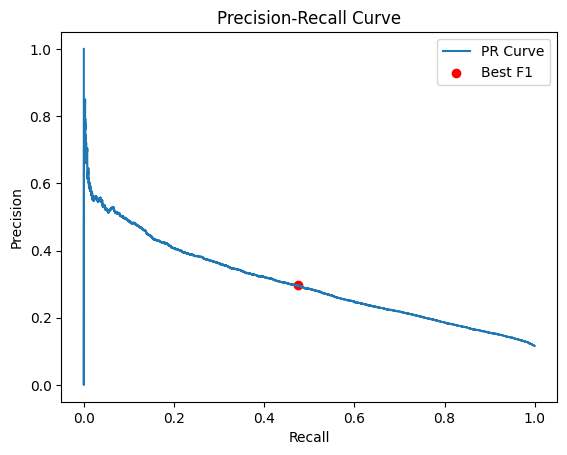

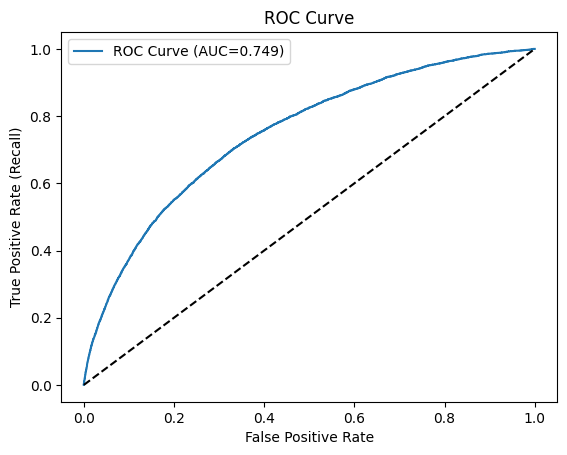

In [18]:
# === Improved SGDClassifier-SVM with threshold tuning & AUC metrics ===

!pip install -q imbalanced-learn
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, roc_curve
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import numpy as np

# 1. Apply SMOTE to oversample defaults
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_scaled, y_train)
print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_res).value_counts().to_dict())

# 2. Train SGDClassifier with balanced weights
sgd_svm = SGDClassifier(loss="hinge", class_weight="balanced", max_iter=2000, tol=1e-3, random_state=42)
sgd_svm.fit(X_res, y_res)

# 3. Evaluate on test set with default threshold (0)
y_test_scores = sgd_svm.decision_function(X_test_scaled)
y_test_pred = (y_test_scores > 0).astype(int)

print("=== Default Threshold (0) ===")
evaluate_and_print(y_test, y_test_pred, label="SGD-SVM + SMOTE (test)")
print("ROC-AUC:", roc_auc_score(y_test, y_test_scores))
print("PR-AUC :", average_precision_score(y_test, y_test_scores))

# 4. Threshold tuning: find best F1
prec, rec, thresholds = precision_recall_curve(y_test, y_test_scores)
f1_scores = 2 * (prec * rec) / (prec + rec + 1e-6)
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
print(f"\nBest threshold by F1: {best_thresh:.3f}, F1={f1_scores[best_idx]:.3f}")

# Apply best threshold
y_test_pred_best = (y_test_scores > best_thresh).astype(int)
print("\n=== Tuned Threshold Results ===")
evaluate_and_print(y_test, y_test_pred_best, label=f"SGD-SVM tuned (thr={best_thresh:.3f})")

# 5. Plots: Precision-Recall and ROC
plt.figure()
plt.plot(rec, prec, label="PR Curve")
plt.scatter(rec[best_idx], prec[best_idx], color="red", label="Best F1")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(); plt.show()

fpr, tpr, _ = roc_curve(y_test, y_test_scores)
plt.figure()
plt.plot(fpr, tpr, label="ROC Curve (AUC=%.3f)" % roc_auc_score(y_test, y_test_scores))
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend(); plt.show()


In [17]:
from sklearn.linear_model import SGDClassifier

sgd_svm = SGDClassifier(loss="hinge", class_weight="balanced", max_iter=1000, tol=1e-3, random_state=42)
sgd_svm.fit(X_train_scaled, y_train)

y_train_pred = sgd_svm.predict(X_train_scaled)
y_test_pred = sgd_svm.predict(X_test_scaled)

print("Train metrics:")
evaluate_and_print(y_train, y_train_pred, label="SGDClassifier-SVM balanced (train)")
print("Test metrics:")
evaluate_and_print(y_test, y_test_pred, label="SGDClassifier-SVM balanced (test)")


Train metrics:
=== SGDClassifier-SVM balanced (train) ===
Train/Test sizes: 204277 / 51070
Accuracy: 0.6572
Sensitivity (Recall for class 1): 0.6890
Specificity (TN / (TN+FP)): 0.6530
Precision: 0.2069
F1 score: 0.3182
Confusion matrix (tn, fp, fn, tp): (np.int64(117903), np.int64(62652), np.int64(7378), np.int64(16344))

Test metrics:
=== SGDClassifier-SVM balanced (test) ===
Train/Test sizes: 204277 / 51070
Accuracy: 0.6587
Sensitivity (Recall for class 1): 0.7065
Specificity (TN / (TN+FP)): 0.6524
Precision: 0.2108
F1 score: 0.3247
Confusion matrix (tn, fp, fn, tp): (np.int64(29450), np.int64(15689), np.int64(1741), np.int64(4190))



In [12]:
# === XGBoost ===
# Uses unscaled features (trees don't need scaling)
!pip install -q xgboost
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb_clf.fit(X_train, y_train)

y_train_pred = xgb_clf.predict(X_train)
y_test_pred = xgb_clf.predict(X_test)

print("Train metrics:")
evaluate_and_print(y_train, y_train_pred, label="XGBoost (train)")
print("Test metrics:")
evaluate_and_print(y_test, y_test_pred, label="XGBoost (test)")


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [16:46:41] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Train metrics:
=== XGBoost (train) ===
Train/Test sizes: 204277 / 51070
Accuracy: 0.8897
Sensitivity (Recall for class 1): 0.0851
Specificity (TN / (TN+FP)): 0.9954
Precision: 0.7084
F1 score: 0.1520
Confusion matrix (tn, fp, fn, tp): (np.int64(179724), np.int64(831), np.int64(21703), np.int64(2019))

Test metrics:
=== XGBoost (test) ===
Train/Test sizes: 204277 / 51070
Accuracy: 0.8869
Sensitivity (Recall for class 1): 0.0713
Specificity (TN / (TN+FP)): 0.9941
Precision: 0.6122
F1 score: 0.1278
Confusion matrix (tn, fp, fn, tp): (np.int64(44871), np.int64(268), np.int64(5508), np.int64(423))



In [13]:
# === GradientBoostingClassifier (sklearn) ===
!pip install -q scikit-learn
from sklearn.ensemble import GradientBoostingClassifier

gb_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_clf.fit(X_train, y_train)

y_train_pred = gb_clf.predict(X_train)
y_test_pred = gb_clf.predict(X_test)

print("Train metrics:")
evaluate_and_print(y_train, y_train_pred, label="GradientBoosting (train)")
print("Test metrics:")
evaluate_and_print(y_test, y_test_pred, label="GradientBoosting (test)")


Train metrics:
=== GradientBoosting (train) ===
Train/Test sizes: 204277 / 51070
Accuracy: 0.8869
Sensitivity (Recall for class 1): 0.0521
Specificity (TN / (TN+FP)): 0.9966
Precision: 0.6661
F1 score: 0.0966
Confusion matrix (tn, fp, fn, tp): (np.int64(179936), np.int64(619), np.int64(22487), np.int64(1235))

Test metrics:
=== GradientBoosting (test) ===
Train/Test sizes: 204277 / 51070
Accuracy: 0.8864
Sensitivity (Recall for class 1): 0.0511
Specificity (TN / (TN+FP)): 0.9962
Precision: 0.6366
F1 score: 0.0946
Confusion matrix (tn, fp, fn, tp): (np.int64(44966), np.int64(173), np.int64(5628), np.int64(303))



In [14]:
# === Decision Tree ===
!pip install -q scikit-learn
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=None, random_state=42)
dt.fit(X_train, y_train)

y_train_pred = dt.predict(X_train)
y_test_pred = dt.predict(X_test)

print("Train metrics:")
evaluate_and_print(y_train, y_train_pred, label="Decision Tree (train)")
print("Test metrics:")
evaluate_and_print(y_test, y_test_pred, label="Decision Tree (test)")


Train metrics:
=== Decision Tree (train) ===
Train/Test sizes: 204277 / 51070
Accuracy: 1.0000
Sensitivity (Recall for class 1): 1.0000
Specificity (TN / (TN+FP)): 1.0000
Precision: 1.0000
F1 score: 1.0000
Confusion matrix (tn, fp, fn, tp): (np.int64(180555), np.int64(0), np.int64(0), np.int64(23722))

Test metrics:
=== Decision Tree (test) ===
Train/Test sizes: 204277 / 51070
Accuracy: 0.8014
Sensitivity (Recall for class 1): 0.2214
Specificity (TN / (TN+FP)): 0.8777
Precision: 0.1921
F1 score: 0.2057
Confusion matrix (tn, fp, fn, tp): (np.int64(39617), np.int64(5522), np.int64(4618), np.int64(1313))



In [15]:
# === Random Forest ===
!pip install -q scikit-learn
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=None, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

print("Train metrics:")
evaluate_and_print(y_train, y_train_pred, label="Random Forest (train)")
print("Test metrics:")
evaluate_and_print(y_test, y_test_pred, label="Random Forest (test)")


Train metrics:
=== Random Forest (train) ===
Train/Test sizes: 204277 / 51070
Accuracy: 1.0000
Sensitivity (Recall for class 1): 1.0000
Specificity (TN / (TN+FP)): 1.0000
Precision: 1.0000
F1 score: 1.0000
Confusion matrix (tn, fp, fn, tp): (np.int64(180555), np.int64(0), np.int64(0), np.int64(23722))

Test metrics:
=== Random Forest (test) ===
Train/Test sizes: 204277 / 51070
Accuracy: 0.8855
Sensitivity (Recall for class 1): 0.0297
Specificity (TN / (TN+FP)): 0.9980
Precision: 0.6592
F1 score: 0.0568
Confusion matrix (tn, fp, fn, tp): (np.int64(45048), np.int64(91), np.int64(5755), np.int64(176))



In [16]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# Take a smaller stratified sample (e.g., 20k rows)
X_train_small, _, y_train_small, _ = train_test_split(
    X_train_scaled, y_train, train_size=20000, stratify=y_train, random_state=42
)

knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_small, y_train_small)

y_train_pred = knn.predict(X_train_small)
y_test_pred = knn.predict(X_test_scaled)

print("Train metrics (20k sample):")
evaluate_and_print(y_train_small, y_train_pred, label="KNN (train subset)")
print("Test metrics:")
evaluate_and_print(y_test, y_test_pred, label="KNN (test)")


Train metrics (20k sample):
=== KNN (train subset) ===
Train/Test sizes: 204277 / 51070
Accuracy: 0.8895
Sensitivity (Recall for class 1): 0.1115
Specificity (TN / (TN+FP)): 0.9917
Precision: 0.6395
F1 score: 0.1899
Confusion matrix (tn, fp, fn, tp): (np.int64(17531), np.int64(146), np.int64(2064), np.int64(259))

Test metrics:
=== KNN (test) ===
Train/Test sizes: 204277 / 51070
Accuracy: 0.8762
Sensitivity (Recall for class 1): 0.0427
Specificity (TN / (TN+FP)): 0.9857
Precision: 0.2821
F1 score: 0.0741
Confusion matrix (tn, fp, fn, tp): (np.int64(44495), np.int64(644), np.int64(5678), np.int64(253))

